### Install the required depedencies

In [ ]:
!pip install lingam category_encoders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 7.1 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=8bfbb5f81ace297b6b8a93a8ab78615f93b884321cd9f9ca0c7256e04e9f56e8
  Stored in directory: /root/.cache/pip/wheels/d2/9a/31/fae291ff6a649bad125037eef8c7cc63d8

In [ ]:
import numpy as np
import pandas as pd
from IPython.display import Image
import category_encoders as ce

import graphviz
import lingam
from lingam.utils import make_dot, make_prior_knowledge
import warnings
warnings.simplefilter('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

display(pd.DataFrame(df.isnull().sum()).T)

df = df.drop(["Cabin"], axis=1)
df = df.dropna(how='any')

display(pd.DataFrame(df.isnull().sum()).T)

display(df.head(3))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,0,0,0,0,177,0,0,0,0,687,2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,0,0,0,0,0,0,0,0,0,0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [ ]:
oe = ce.ordinal.OrdinalEncoder(
    cols=df.select_dtypes(include="object")
    )

df_en = oe.fit_transform(df)

### LiNGAM - Linear Non-Gaussian Acyclic Model

LiNGAM is a causal discovery algorithm that assumes:

1. Linear relationships
2. Non-Gaussian noise
3. Acyclic causal graph

It outputs a Directed Acyclic Graph (DAG) where edges represent causal influence.

create a dictionary of features and index

In [ ]:
df_list = df_en.drop("PassengerId", axis=1).columns.to_list()
df_dict = {}

for i, column in zip(range(len(df_list)), df_list):
    df_dict[column] = i

print(len(df_list))
print(df_dict)

10
{'Survived': 0, 'Pclass': 1, 'Name': 2, 'Sex': 3, 'Age': 4, 'SibSp': 5, 'Parch': 6, 'Ticket': 7, 'Fare': 8, 'Embarked': 9}


Setting prior knowledge

In [ ]:
prior_knowledge = make_prior_knowledge(
    10,
    exogenous_variables=[
        df_dict["Sex"],
        df_dict["Age"]
    ],
    sink_variables=[
        df_dict["Survived"]
    ],
    no_paths = [
    [df_dict["Survived"], df_dict["Embarked"]],
    [df_dict["Survived"], df_dict["Sex"]],
]
)


In [ ]:
model = lingam.DirectLiNGAM(
                    random_state=42,
                    measure = 'pwling', # kernel
                    prior_knowledge = prior_knowledge
                    )

model.fit(df_en.drop("PassengerId", axis=1))

### view causal graph

In [ ]:
dot = make_dot(
    model.adjacency_matrix_,
     labels=df_en.drop("PassengerId", axis=1).columns.to_list(),
    )

dot.format = 'png'
dot.render('dag')

'dag.png'

Add correlation coefficient

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42)
clf.fit(df_en.drop(["PassengerId", "Survived"], axis=1), df_en["Survived"])

LogisticRegression(random_state=42)

features:  [0, 1, 2, 3, 4, 5, 6, 7, 8]


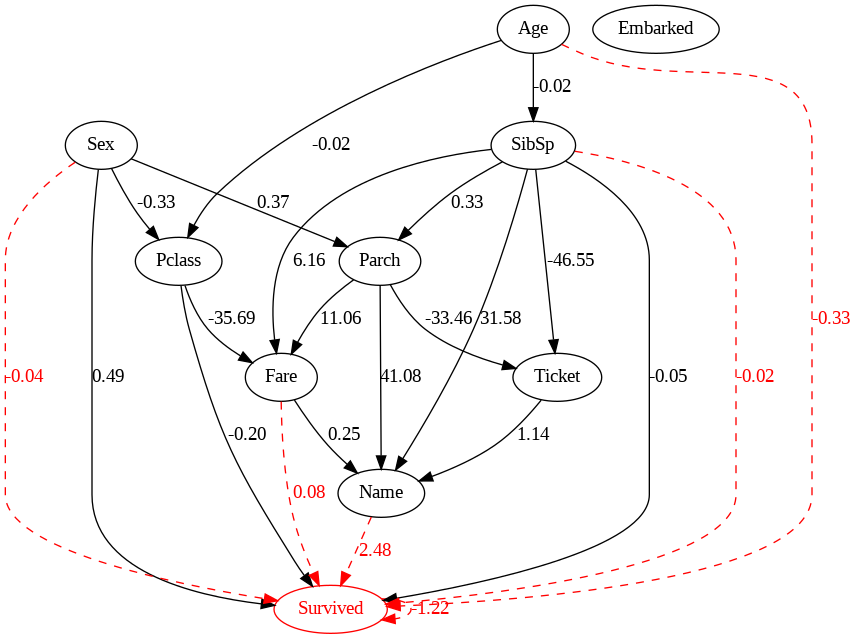

In [ ]:
features = [i for i in range(df_en.drop(["PassengerId", "Survived"], axis=1).shape[1])]
print("features: ", features)

dot = make_dot(
    model.adjacency_matrix_,
    labels=df_en.drop("PassengerId", axis=1).columns.to_list(),
    prediction_feature_indices=features,
    prediction_target_label='Survived',
    prediction_coefs=clf.coef_[0]
    )
dot.format = 'png'
dot.render('dag')

Image("dag.png")

In [ ]:
## lightGBM
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
clf = lgb.LGBMClassifier(random_state=42)
clf.fit(df_en.drop(["PassengerId", "Survived"], axis=1), df_en["Survived"])

[LightGBM] [Info] Number of positive: 288, number of negative: 424
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.404494 -> initscore=-0.386773
[LightGBM] [Info] Start training from score -0.386773
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(random_state=42)

**EVALUATION**

In [ ]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# split the dataset to train and test sets
X = df_en.drop(["PassengerId", "Survived"], axis=1)
y = df_en["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# re-train on train split
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# evaluation
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nFull Classification Report:\n", classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 225, number of negative: 344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 566
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.395431 -> initscore=-0.424541
[LightGBM] [Info] Start training from score -0.424541
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


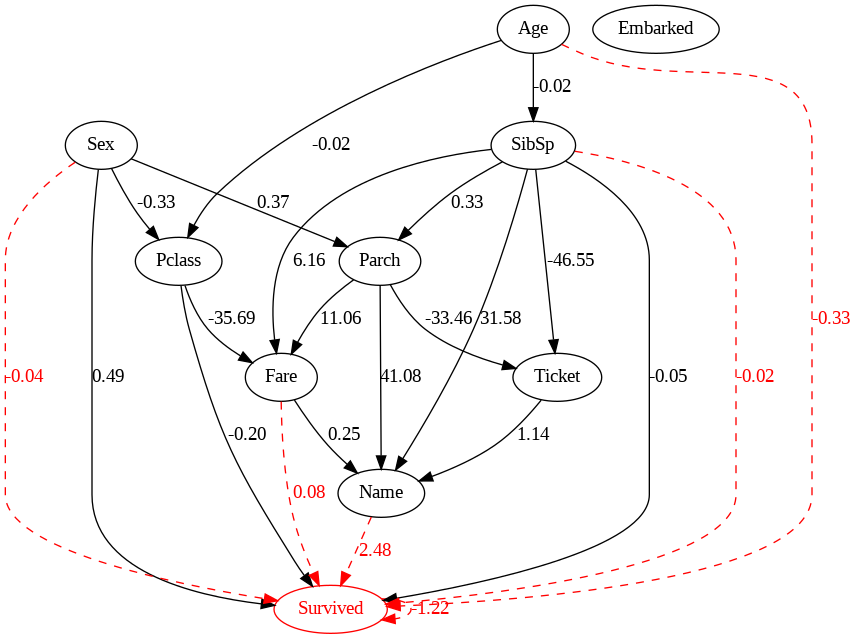

In [ ]:
dot = make_dot(
    model.adjacency_matrix_,
    labels=df_en.drop("PassengerId", axis=1).columns.to_list(),
    prediction_feature_indices=features,
    prediction_target_label='Survived',
    prediction_coefs=clf.feature_importances_
    )

# save image
dot.render('dag')

Image("dag.png")

**finding features that had the most causal impact on the prediction**

In [ ]:
lce = lingam.CausalEffect(model)
effects = lce.estimate_effects_on_prediction(
                                    df_en.drop(["PassengerId"], axis=1),
                                    df.columns.to_list().index("Survived"), # specify the index of target variable Survived
                                    clf
                                    )


df_effects = pd.DataFrame()
df_effects['feature'] = df_en.drop(["PassengerId"], axis=1).columns
df_effects['effect_plus'] = effects[:, 0]
df_effects['effect_minus'] = effects[:, 1]*-1
display(df_effects)

max_index = np.unravel_index(np.argmax(effects), effects.shape)
print(df_en.drop(["PassengerId"], axis=1).columns[max_index[0]])

,feature,effect_plus,effect_minus
0,Survived,0.000000,-0.000000
1,Pclass,0.021227,-0.901318
2,Name,0.004659,-0.081338
3,Sex,1.583726,-0.102911
4,Age,0.079473,-0.806973
5,SibSp,0.162173,-0.161730
6,Parch,0.116470,-0.513722
7,Ticket,0.092863,-0.067273
8,Fare,0.391087,-0.021227
9,Embarked,0.021217,-0.000000


Sex


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['effect_plus'].plot(kind='hist', bins=20, title='effect_plus')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['effect_minus'].plot(kind='hist', bins=20, title='effect_minus')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['index']
  ys = series['effect_minus']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_6.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('effect_minus')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_8['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['effect_plus'].plot(kind='line', figsize=(8, 4), title='effect_plus')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['effect_minus'].plot(kind='line', figsize=(8, 4), title='effect_minus')
plt.gca().spines[['top', 'right']].set_visible(False)

influence of sample features

In [ ]:
column_x = "SibSp"
column_y = "Pclass"

te = model.estimate_total_effect(df_en.drop(["PassengerId"], axis=1), df_dict[column_x], df_dict[column_y])
print(f'Total influence from {df_dict[column_x]}:{column_x} to {df_dict[column_y]}:{column_y}: {te:.3f}')

Total influence from 5:SibSp to 1:Pclass: -0.047
